In [ ]:
import json
import re
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams["font.family"] = "Nirmala UI"



train_json_path = fr"nepali_captions\vatex_train_ne.json"
val_json_path = fr"nepali_captions\vatex_val_ne.json"



def load_captions(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    captions = []
    for item in data:
        if "caption" in item:
            captions.extend(item["caption"])
    return captions

train_captions = load_captions(train_json_path)
val_captions = load_captions(val_json_path)

all_captions = train_captions + val_captions

print("Train captions:", len(train_captions))
print("Val captions:", len(val_captions))
print("Total captions:", len(all_captions))

all_words = []
for caption in all_captions:
    caption = str(caption).strip()
    caption = re.sub(r"[।,!?\"'“”‘’()\-]", "", caption)
    words = caption.split()
    all_words.extend(words)

word_counts = Counter(all_words)
top_10_words = word_counts.most_common(10)

print("\nTop 10 most frequent words:")
for word, count in top_10_words:
    print(f"{word}: {count}")

Train captions: 213850
Val captions: 24860
Total captions: 238710

Top 10 most frequent words:
एक: 106799
र: 90403
छ: 54587
छन्: 41235
एउटी: 39213
व्यक्तिले: 37312
एउटा: 36050
आफ्नो: 30877
प्रयोग: 20229
छिन्: 19733


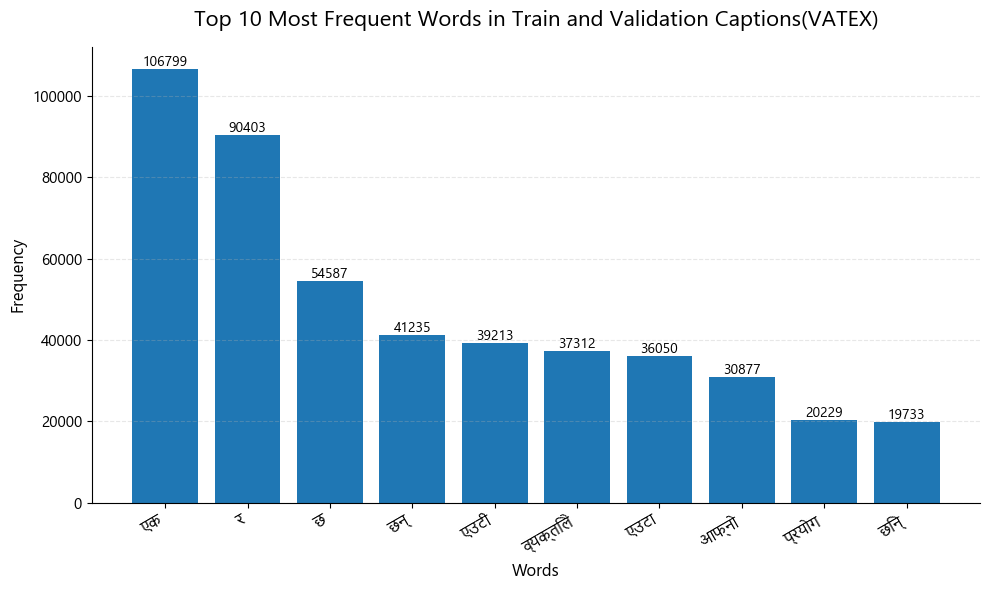

In [11]:
words = [word for word, count in top_10_words]
counts = [count for word, count in top_10_words]

plt.figure(figsize=(10, 6))
bars = plt.bar(words, counts)

plt.title("Top 10 Most Frequent Words in Train and Validation Captions(VATEX)", fontsize=16, pad=15)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xticks(rotation=30, ha="right", fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        str(count),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [12]:
def load_captions(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    captions = []
    for item in data:
        captions.extend(item.get("caption", []))
    return captions

train_captions = load_captions(train_json_path)
val_captions = load_captions(val_json_path)
all_captions = train_captions + val_captions

caption_lengths = [len(str(caption).split()) for caption in all_captions]


min_len = min(caption_lengths)
max_len = max(caption_lengths)

shortest_captions = [c for c in all_captions if len(str(c).split()) == min_len]
longest_captions = [c for c in all_captions if len(str(c).split()) == max_len]


print("Total captions:", len(all_captions))
print("Minimum caption length:", min(caption_lengths))
print("Maximum caption length:", max(caption_lengths))
print("Average caption length:", sum(caption_lengths) / len(caption_lengths))


print("\nExample shortest caption:")
print(shortest_captions[0])

print("\nExample longest caption:")
print(longest_captions[0])

Total captions: 238710
Minimum caption length: 3
Maximum caption length: 48
Average caption length: 10.876645301830672

Example shortest caption:
बच्चालाई समातेर हल्लाइरहन्छ।

Example longest caption:
स्विमसुट लगाएकी एउटी केटी चट्टानबाट पानीको शरीरमा हाम फाल्छिन्, अर्की केटी चट्टानमा उभिरहेकी छिन्, एक व्यक्ति जेट स्कीमा बसिरहेकी छिन् र विभिन्न मानिसहरू पानीमा डुङ्गामा बसेर उभिरहेका छन्, दुई केटीहरू डुङ्गामा हाँस्छन्, र त्यसपछि माइक्रोफोन भएको एक व्यक्तिले केटीसँग कुरा गर्छ जबकि मानिसहरूको ठूलो समूह पृष्ठभूमिमा डुङ्गामा उभिन्छ।


In [ ]:
# Extract all captions (flattened)
def extract_captions(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    captions = []

    for item in data:
        if "caption" in item:
            captions.extend(item["caption"]) 

    return captions


#  Build vocabulary
def build_vocab(captions):
    vocab = set()

    for cap in captions:
        words = cap.split()   # basic tokenization
        vocab.update(words)

    return vocab


# Load captions
train_caps = extract_captions(train_json_path)
val_caps = extract_captions(val_json_path)

all_caps = train_caps + val_caps

# Compute vocabulary
vocab = build_vocab(all_caps)

# Results
print(f"Total captions: {len(all_caps)}")
print(f"Total vocabulary size: {len(vocab)}")

# Print some words
print("\nSample words from vocab:")
print(list(vocab)[:50])

Total captions: 238710
Total vocabulary size: 52732

Sample words from vocab:
['उतार्दैछ।', 'सुताउँछिन्', 'कार्यात्मक', 'लाग्नबाट', 'रिटाइदिन्छ', 'ट्राम्पोलिनबाट', 'फ्यानबाट', 'निभिया', 'आगलागीबाट', 'पिण्डले', 'अभिभावकलाई', 'बोलिन्।', 'ब्यान्डसहित', 'अन्तर्क्रियात्मक', 'स्नोब्लेड', 'टर्निङ', 'स्न्यागहरू', 'बिरालाको', 'वर्गसँग', 'अर्ब', 'अड्किएको', 'वाशरहरूलाई', 'फोटोहरूको', 'हस्तलेखन', 'फल्याकबाट', 'नुनका', 'कुआमी', 'अखबारसँग', 'ऐनमा', 'पोलेसाले', 'भएकाले,', 'मुजाक', 'सरकारको', 'जहाजलाई', 'बेसबोर्डहरू', 'चलिरहन्छन्।', 'लगाउँदै।', 'रंग्यो।', 'स्पेल', 'हड्डीहरू', 'लगिन्छ।', 'वाटरस्लाइडबाट', 'खौर्छिन्,', 'पदार्थ,', 'विवरणबारे', 'मफ्ल', 'वाटर-स्की', 'अर्कीको', 'चिच्याउने', 'एरेनाको']
